[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/energy-system-modeling/blob/main/notebooks/p4_networks/pipeline_transport.ipynb)

# Module 3: Energy Transportation and Network Optimization
## REE 4301 / IE 5300 - Energy Systems Modeling

Moving energy costs money, and where it can go is limited. This notebook builds the classic transportation problem three ways and shows they are the same problem.

**Read it in order.** It goes:

1. **By hand, in gurobipy** - all five parts of the linear program visible, numbered, and yours.
2. **In PyPSA**, one component at a time, with each argument mapped back to the symbol it replaces.
3. **Then the interactive versions** - sliders that let you push the pipeline capacity around and watch the answer move.

The sliders come last on purpose. Dragging one before you know what is underneath it teaches you the shape of a curve and nothing about the model. Once you have written the constraints yourself, the same slider is an experiment.


In [1]:
!pip install -q pypsa highspy

In [2]:
# Install the Gurobi Python package (required for Google Colab)
!pip install gurobipy

import gurobipy as gp
from gurobipy import GRB

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import linprog
import ipywidgets as widgets
from IPython.display import display

---
# Part A - The transport problem by hand, in gurobipy

The five parts, numbered, in the order you will write them for every model in this course. Watch for the capacity constraint: it can be switched on and off, and that switch is the whole lesson.


## Gurobi Example w/ Togglable Pipeline Limit


In [4]:


# ==========================================
# 0. Constraint Toggle
# ==========================================
# Change this to False to remove the pipeline limit
USE_INFRASTRUCTURE_CONSTRAINT = True

# ==========================================
# 1. Sets and Parameters (Data)
# ==========================================
supply_nodes = ['Permian', 'Eagle Ford']
demand_nodes = ['Houston', 'Corpus Christi', 'Beaumont']

# Supply available (in thousands of bbl/d)
supply = {
    'Permian': 100,
    'Eagle Ford': 80
}

# Demand required (in thousands of bbl/d)
demand = {
    'Houston': 70,
    'Corpus Christi': 60,
    'Beaumont': 50
}

# Tariff Matrix / Costs ($ per barrel)
costs = {
    ('Permian', 'Houston'): 3.00,
    ('Permian', 'Corpus Christi'): 4.50,
    ('Permian', 'Beaumont'): 3.50,
    ('Eagle Ford', 'Houston'): 2.50,
    ('Eagle Ford', 'Corpus Christi'): 1.50,
    ('Eagle Ford', 'Beaumont'): 4.00
}

# ==========================================
# 2. Model Initialization
# ==========================================
# Create a new model
m = gp.Model("Texas_Crude_Oil_Routing")

# Disable console output if you want a cleaner printout (optional)
#m.setParam('OutputFlag', 0)

# ==========================================
# 3. Decision Variables
# ==========================================
routes = costs.keys()
x = m.addVars(routes, vtype=GRB.CONTINUOUS, name="route")

# ==========================================
# 4. Objective Function
# ==========================================
m.setObjective(x.prod(costs), GRB.MINIMIZE)

# ==========================================
# 5. Constraints
# ==========================================
# Base Supply and Demand constraints
m.addConstrs((gp.quicksum(x[i, j] for j in demand_nodes) == supply[i]
              for i in supply_nodes), name="Supply")

m.addConstrs((gp.quicksum(x[i, j] for i in supply_nodes) == demand[j]
              for j in demand_nodes), name="Demand")

# NEW: Toggleable Infrastructure Constraint
if USE_INFRASTRUCTURE_CONSTRAINT:
    # Limit Eagle Ford -> Corpus Christi to 50k bbl/d (units are in 1000s)
    m.addConstr(x['Eagle Ford', 'Corpus Christi'] <= 50, name="Capacity_EC")

# ==========================================
# 6. Optimize and Output
# ==========================================
m.optimize()

# Print the solution gracefully
if m.status == GRB.OPTIMAL:
    print("-" * 45)
    print(f"OPTIMAL ROUTING (Pipeline Limit Active: {USE_INFRASTRUCTURE_CONSTRAINT})")
    print("-" * 45)
    for i, j in routes:
        if x[i, j].X > 1e-6:
            print(f"Ship {x[i,j].X:5.1f}k bbl/d from {i} to {j}")

    print("-" * 45)
    print(f"Total Minimum Cost: ${m.ObjVal * 1000:,.2f} / day")
else:
    print("No optimal solution found.")

CPU model: Intel(R) Core(TM) i9-10900 CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]


Thread count: 10 physical cores, 20 logical processors, using up to 20 threads


Optimize a model with 6 rows, 6 columns and 13 nonzeros (Min)


Model fingerprint: 0x4f1b678a


Model has 6 linear objective coefficients


...

       0    4.7000000e+02   5.000000e+00   0.000000e+00      0s


       1    4.9000000e+02   0.000000e+00   0.000000e+00      0s


Solved in 1 iterations and 0.01 seconds (0.00 work units)


Optimal objective  4.900000000e+02


---------------------------------------------
OPTIMAL ROUTING (Pipeline Limit Active: True)
---------------------------------------------
Ship  40.0k bbl/d from Permian to Houston
Ship  10.0k bbl/d from Permian to Corpus Christi
Ship  50.0k bbl/d from Permian to Beaumont
Ship  30.0k bbl/d from Eagle Ford to Houston
Ship  50.0k bbl/d from Eagle Ford to Corpus Christi
---------------------------------------------
Total Minimum Cost: $490,000.00 / day


To determine exactly how much of a kickback your buddy needs to offer to change your routing strategy, we use a concept in Linear Programming called Sensitivity Analysis (which is closely related to Reduced Costs and Shadow Prices).Since Permian $\rightarrow$ Houston is already used in the optimal plan (we send 40k bbl/d there currently), its Reduced Cost is $0. However, Gurobi can calculate the Objective Allowable Decrease/Increase. This tells us exactly how much the price of a route can fluctuate before the math forces us to change our entire routing plan (e.g., sending more than 40k down that pipeline).Here is the Gurobi code to explore this. You can copy and paste this directly into Colab!Gurobi Code for Sensitivity Analysis (Kickbacks)


What This Tells You About the KickbackWhen you run this code, you will look at the SAObjLow (Sensitivity Analysis Objective Lower Bound) for the Permian $\rightarrow$ Houston route.It will reveal that the cost of Permian $\rightarrow$ Houston needs to drop from $3.00 down to $2.00 (a $1.00 kickback) before it makes economic sense to alter the plan.Why $1.00?If your buddy gives you a $1.00 kickback, the Permian $\rightarrow$ Houston route drops to $2.00. At $2.00, it is suddenly significantly cheaper than the Eagle Ford $\rightarrow$ Houston route ($2.50). The solver will completely re-route the system, maxing out the Houston demand purely from the Permian basin and forcing Eagle Ford oil to be routed toward Beaumont instead!Reduced Costs vs. Shadow PricesReduced Costs / Objective Boundaries (used above): Apply to your routes. They tell you exactly how much your unit economics (shipping tariffs/kickbacks) must change to trigger a new routing plan.Shadow Prices (bonus at the bottom of the code): Apply to your constraints. It tells you that every extra barrel of capacity you can squeeze into the bottlenecked Eagle Ford $\rightarrow$ Corpus Christi pipeline saves the entire system $2.50.

## Gurobi Sensitivity Analysis

In [5]:
# ==========================================
# 1. Sets and Parameters
# ==========================================
supply_nodes = ['Permian', 'Eagle Ford']
demand_nodes = ['Houston', 'Corpus Christi', 'Beaumont']

supply = {'Permian': 100, 'Eagle Ford': 80}
demand = {'Houston': 70, 'Corpus Christi': 60, 'Beaumont': 50}

costs = {
    ('Permian', 'Houston'): 3.00,
    ('Permian', 'Corpus Christi'): 4.50,
    ('Permian', 'Beaumont'): 3.50,
    ('Eagle Ford', 'Houston'): 2.50,
    ('Eagle Ford', 'Corpus Christi'): 1.50,
    ('Eagle Ford', 'Beaumont'): 4.00
}

# ==========================================
# 2. Model Initialization & Variables
# ==========================================
m = gp.Model("Texas_Crude_Oil_Routing_Kickback")
m.setParam('OutputFlag', 0)

routes = costs.keys()
x = m.addVars(routes, vtype=GRB.CONTINUOUS, name="route")

m.setObjective(x.prod(costs), GRB.MINIMIZE)

# ==========================================
# 3. Constraints
# ==========================================
m.addConstrs((gp.quicksum(x[i, j] for j in demand_nodes) == supply[i]
              for i in supply_nodes), name="Supply")

m.addConstrs((gp.quicksum(x[i, j] for i in supply_nodes) == demand[j]
              for j in demand_nodes), name="Demand")

# Infrastructure limit
pipeline_limit = m.addConstr(x['Eagle Ford', 'Corpus Christi'] <= 50, name="Capacity_EC")

# ==========================================
# 4. Optimize
# ==========================================
m.optimize()

# ==========================================
# 5. Output: The "Kickback" Analysis
# ==========================================
if m.status == GRB.OPTIMAL:
    print("=" * 70)
    print(f"{'ROUTE':<30} | {'CURRENT COST':<15} | {'PRICE TO CHANGE PLAN':<20}")
    print("=" * 70)

    for i, j in routes:
        current_cost = costs[(i, j)]
        # SAObjLow is the lowest the cost can go before we use MORE of this route
        # SAObjUp is the highest the cost can go before we use LESS of this route
        lower_bound = x[i, j].SAObjLow

        route_name = f"{i} -> {j}"

        # If the lower bound is negative infinity, it means no matter how cheap it gets,
        # we physically cannot send more (due to supply/demand limits).
        if lower_bound == -GRB.INFINITY:
            lower_bound_str = "-Infinity"
        else:
            lower_bound_str = f"${lower_bound:.2f}"

        print(f"{route_name:<30} | ${current_cost:<14.2f} | Drops below {lower_bound_str}")

    print("\n" + "=" * 70)
    print("PIPELINE SHADOW PRICE (Eagle Ford -> Corpus Christi limit)")
    print("=" * 70)
    # The Pi attribute on a constraint gives its shadow price
    print(f"If we expanded this pipeline by 1,000 bbl/d, we would save ${-pipeline_limit.Pi * 1000:,.2f} per day.")

else:
    print("No optimal solution found.")

ROUTE                          | CURRENT COST    | PRICE TO CHANGE PLAN
Permian -> Houston             | $3.00           | Drops below $2.00
Permian -> Corpus Christi      | $4.50           | Drops below $2.00
Permian -> Beaumont            | $3.50           | Drops below $-inf
Eagle Ford -> Houston          | $2.50           | Drops below $0.00
Eagle Ford -> Corpus Christi   | $1.50           | Drops below $-inf
Eagle Ford -> Beaumont         | $4.00           | Drops below $3.00

PIPELINE SHADOW PRICE (Eagle Ford -> Corpus Christi limit)
If we expanded this pipeline by 1,000 bbl/d, we would save $2,500.00 per day.


### Discussion Questions (Part A)

1. At what slider value does the Eagle Ford → Corpus pipe first turn **red** (hit its capacity limit)?
2. How much does the total daily tariff increase when the pipe is constrained from 80k to 50k bbl/d?
3. What happens if you set the capacity to 20k? Where does the solver route the remaining 40k barrels for Corpus?

---
# Part B - The same problem in PyPSA, one component at a time

Everything you just wrote by hand - the balance equations, the capacity limits, the objective - gets written for you here. What you supply instead is a description of the *system*.

Each step below names the PyPSA argument and the LP symbol it replaces. That mapping is the point of this section: `Link.p_nom` is not a new idea, it is the capacity constraint you already wrote.


### Step 1: Initialize the Network and Define the Carrier

In [6]:
import pypsa
import warnings
warnings.filterwarnings('ignore')

In [7]:


n = pypsa.Network()

# Define the Carrier (the physical commodity being moved)
n.add("Carrier", "crude_oil")

# Add the Supply and Demand Nodes (Buses)
buses = ["Permian", "Eagle Ford", "Houston", "Corpus", "Beaumont"]
for b in buses:
    n.add("Bus", b, carrier="crude_oil")

print("Buses in the network:")
print(n.buses)

Buses in the network:
            v_nom type    x    y    carrier unit location  v_mag_pu_set  \
name                                                                      
Permian       1.0       0.0  0.0  crude_oil                         1.0   
Eagle Ford    1.0       0.0  0.0  crude_oil                         1.0   
Houston       1.0       0.0  0.0  crude_oil                         1.0   
Corpus        1.0       0.0  0.0  crude_oil                         1.0   
Beaumont      1.0       0.0  0.0  crude_oil                         1.0   

            v_mag_pu_min  v_mag_pu_max control generator sub_network  
name                                                                  
Permian              0.0           inf      PQ                        
Eagle Ford           0.0           inf      PQ                        
Houston              0.0           inf      PQ                        
Corpus               0.0           inf      PQ                        
Beaumont             0.0  

### Step 2: Define Supply Constraints (Generators)

In [8]:
# Supply Nodes — Generators with a maximum capacity
# Generator.p_nom maps to the Supply limit S_i
n.add("Generator", "Permian_Supply",
      bus="Permian", p_nom=100000, marginal_cost=0)
n.add("Generator", "Eagle_Ford_Supply",
      bus="Eagle Ford", p_nom=80000, marginal_cost=0)

print("Generators (Supply Nodes):")
print(n.generators[['bus', 'p_nom', 'marginal_cost']])

Generators (Supply Nodes):
                          bus     p_nom  marginal_cost
name                                                  
Permian_Supply        Permian  100000.0            0.0
Eagle_Ford_Supply  Eagle Ford   80000.0            0.0


### Step 3: Define Demand Constraints (Loads)

In [9]:
# Demand Nodes — Loads with a fixed requirement
# Load.p_set maps to the Demand requirement D_j
n.add("Load", "Houston_Demand",  bus="Houston",  p_set=70000)
n.add("Load", "Corpus_Demand",   bus="Corpus",   p_set=60000)
n.add("Load", "Beaumont_Demand", bus="Beaumont", p_set=50000)

print("Loads (Demand Nodes):")
print(n.loads[['bus', 'p_set']])

Loads (Demand Nodes):
                      bus    p_set
name                              
Houston_Demand    Houston  70000.0
Corpus_Demand      Corpus  60000.0
Beaumont_Demand  Beaumont  50000.0


### Step 4: Add the Infrastructure — Pipelines as Links

In [10]:
# Links = directed transport routes
# Link.marginal_cost maps to the Tariff c_ij
# Link.p_nom maps to the Pipeline capacity Cap_ij

n.add("Link", "Pipe_Permian_Houston",
      bus0="Permian", bus1="Houston",
      marginal_cost=3.00, p_nom=60000)  # Capacity constraint!

n.add("Link", "Pipe_Permian_Corpus",
      bus0="Permian", bus1="Corpus",
      marginal_cost=4.50, p_nom=999999)

n.add("Link", "Pipe_Permian_Beaumont",
      bus0="Permian", bus1="Beaumont",
      marginal_cost=3.50, p_nom=999999)

n.add("Link", "Pipe_EagleFord_Houston",
      bus0="Eagle Ford", bus1="Houston",
      marginal_cost=2.50, p_nom=999999)

n.add("Link", "Pipe_EagleFord_Corpus",
      bus0="Eagle Ford", bus1="Corpus",
      marginal_cost=1.50, p_nom=50000)  # BOTTLENECK!

n.add("Link", "Pipe_EagleFord_Beaumont",
      bus0="Eagle Ford", bus1="Beaumont",
      marginal_cost=4.00, p_nom=999999)

print("Links (Pipelines):")
print(n.links[['bus0', 'bus1', 'marginal_cost', 'p_nom']])

Links (Pipelines):
                               bus0      bus1  marginal_cost     p_nom
name                                                                  
Pipe_Permian_Houston        Permian   Houston            3.0   60000.0
Pipe_Permian_Corpus         Permian    Corpus            4.5  999999.0
Pipe_Permian_Beaumont       Permian  Beaumont            3.5  999999.0
Pipe_EagleFord_Houston   Eagle Ford   Houston            2.5  999999.0
Pipe_EagleFord_Corpus    Eagle Ford    Corpus            1.5   50000.0
Pipe_EagleFord_Beaumont  Eagle Ford  Beaumont            4.0  999999.0


### Step 5: Solve and Interpret Results

In [11]:
# Solve the LP — PyPSA builds the constraint matrix automatically
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"\nTotal System Cost: ${n.objective * 1000:,.0f} per day")
print(f"\n--- Optimal Pipeline Flows (bbl/d) ---")
print(n.links_t.p0.T)

INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.io: Writing time: 0.04s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 8 primals, 21 duals
Objective: 4.90e+05
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


Solver Status: ok

Total System Cost: $490,000,000 per day

--- Optimal Pipeline Flows (bbl/d) ---
snapshot                     now
name                            
Pipe_Permian_Houston     40000.0
Pipe_Permian_Corpus      10000.0
Pipe_Permian_Beaumont    50000.0
Pipe_EagleFord_Houston   30000.0
Pipe_EagleFord_Corpus    50000.0
Pipe_EagleFord_Beaumont     -0.0


### Step 6: Visualize the Optimized Network

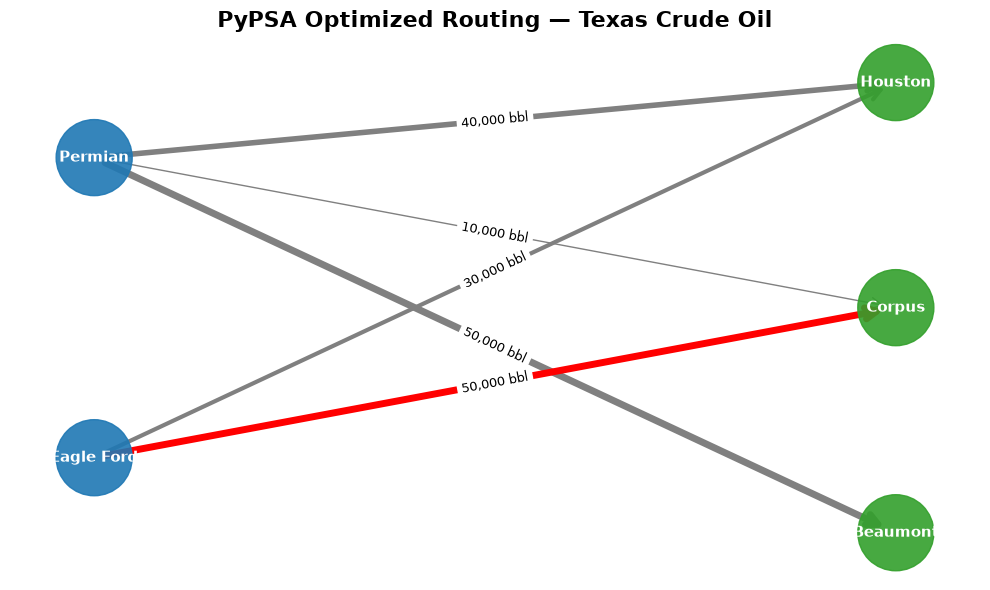


--- Key Insight ---
Eagle Ford → Corpus bottleneck (50k cap) forced 
10,000 bbl through the $4.50 Permian → Corpus route.
Infrastructure constraints, not unit economics, dictate total system cost.


In [12]:
# Extract flows for visualization
flows = n.links_t.p0.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
G = nx.DiGraph()
pos = {
    'Permian': (0, 2), 'Eagle Ford': (0, 0),
    'Houston': (2, 2.5), 'Corpus': (2, 1), 'Beaumont': (2, -0.5)
}
G.add_nodes_from(pos.keys())

# Map link names to source/dest
link_map = {
    'Pipe_Permian_Houston':    ('Permian', 'Houston'),
    'Pipe_Permian_Corpus':     ('Permian', 'Corpus'),
    'Pipe_Permian_Beaumont':   ('Permian', 'Beaumont'),
    'Pipe_EagleFord_Houston':  ('Eagle Ford', 'Houston'),
    'Pipe_EagleFord_Corpus':   ('Eagle Ford', 'Corpus'),
    'Pipe_EagleFord_Beaumont': ('Eagle Ford', 'Beaumont'),
}

for link_name, (src, dst) in link_map.items():
    flow_val = flows[link_name]
    if flow_val > 0.1:
        G.add_edge(src, dst, weight=flow_val)

nx.draw_networkx_nodes(G, pos, node_size=3000,
                       node_color=['#1f78b4', '#1f78b4',
                                   '#33a02c', '#33a02c', '#33a02c'],
                       alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=11,
                        font_color='white', font_weight='bold', ax=ax)

edge_widths = [G[u][v]['weight'] / 10000 for u, v in G.edges()]
edge_colors = ['red' if (u == 'Eagle Ford' and v == 'Corpus')
               else 'gray' for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, width=edge_widths,
                       edge_color=edge_colors, arrowsize=20,
                       arrowstyle='->', ax=ax)

edge_labels = {(u, v): f"{G[u][v]['weight']:,.0f} bbl"
               for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_color='black', font_size=9, ax=ax)

ax.set_title("PyPSA Optimized Routing — Texas Crude Oil",
             fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n--- Key Insight ---")
print(f"Eagle Ford → Corpus bottleneck (50k cap) forced ")
print(f"{flows['Pipe_Permian_Corpus']:,.0f} bbl through the $4.50 Permian → Corpus route.")
print(f"Infrastructure constraints, not unit economics, dictate total system cost.")

### Discussion Questions (Part B)

1. Compare the SciPy and PyPSA solutions at the same slider value. Are the optimal flows identical? Why?
2. In the SciPy version, you manually coded `A_eq`. Where did that matrix go in the PyPSA version?
3. If you wanted to switch from pipeline (controllable) routing to electrical grid (physics-based) routing, what single change would you make in PyPSA?

---
# Part C - Now go and play with it

Both cells below wrap what you have just built into a function with a slider on it. **They are here rather than at the top deliberately.** You have written the constraints; now you can push them around and the movement will mean something.

> **Predict before you drag.** Pick a pipeline capacity, write down which route you think the oil reroutes through and what that does to the total cost, and only then move the slider.

The first is the SciPy version, the second is the PyPSA one. They solve the same problem and should agree.


---
# Part A: SciPy LP Solver — Interactive Visualizer

This section solves the **Texas Crude Oil Transportation Problem** using `scipy.optimize.linprog`.

**The Scenario:**
- 2 Supply Nodes: Permian Basin (100k bbl/d), Eagle Ford (80k bbl/d)
- 3 Demand Nodes: Houston (70k), Corpus Christi (60k), Beaumont (50k)
- The system is perfectly balanced (180k supply = 180k demand)

**The Interactive Element:**
Use the slider to constrain the Eagle Ford → Corpus pipeline capacity and watch the solver reroute oil through more expensive paths.

### Mapping to the 5-Part Optimization Framework
| Framework Part | Code Element |
|---|---|
| 1. Sets | `supply_nodes`, `demand_nodes` |
| 2. Parameters | `supply`, `demand`, `costs` |
| 3. Decision Variables | `bounds` (one per route) |
| 4. Objective Function | `costs` vector passed to `linprog` |
| 5. Constraints | `A_eq`, `b_eq` (nodal balance) + `bounds` (capacity) |

In [13]:
def solve_and_visualize(ec_capacity):
    """
    Solves the Texas Crude Oil Transportation Problem and visualizes the network.
    """
    # ---------------------------------------------------------
    # PART 1 & 2: SETS AND PARAMETERS (The Hard Data)
    # ---------------------------------------------------------
    supply_nodes = ['Permian', 'Eagle Ford']
    demand_nodes = ['Houston', 'Corpus', 'Beaumont']

    # Supply available (in thousands of barrels)
    supply = [100, 80]

    # Demand required (in thousands of barrels)
    demand = [70, 60, 50]

    # Tariff vector: P->H, P->C, P->B, E->H, E->C, E->B
    costs = [3.0, 4.5, 3.5, 2.5, 1.5, 4.0]

    # ---------------------------------------------------------
    # PART 3: DECISION VARIABLES & BOUNDS
    # ---------------------------------------------------------
    # 6 routes — each has a lower bound of 0.
    # We apply the slider value to the Eagle Ford -> Corpus pipe (Index 4).
    bounds = [
        (0, None),         # Permian -> Houston
        (0, None),         # Permian -> Corpus
        (0, None),         # Permian -> Beaumont
        (0, None),         # Eagle Ford -> Houston
        (0, ec_capacity),  # Eagle Ford -> Corpus (BOTTLENECK)
        (0, None)          # Eagle Ford -> Beaumont
    ]

    # ---------------------------------------------------------
    # PART 4 & 5: OBJECTIVE FUNCTION & CONSTRAINTS
    # ---------------------------------------------------------
    # A_eq and b_eq encode the nodal balance constraints.
    # Row 1: Permian Supply    (x_PH + x_PC + x_PB = 100)
    # Row 2: Eagle Ford Supply (x_EH + x_EC + x_EB = 80)
    # Row 3: Houston Demand    (x_PH + x_EH = 70)
    # Row 4: Corpus Demand     (x_PC + x_EC = 60)
    # Row 5: Beaumont Demand   (x_PB + x_EB = 50)

    A_eq = [
        [1, 1, 1, 0, 0, 0],  # Permian
        [0, 0, 0, 1, 1, 1],  # Eagle Ford
        [1, 0, 0, 1, 0, 0],  # Houston
        [0, 1, 0, 0, 1, 0],  # Corpus
        [0, 0, 1, 0, 0, 1]   # Beaumont
    ]
    b_eq = [100, 80, 70, 60, 50]

    # Solve the Linear Program
    res = linprog(costs, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

    if not res.success:
        print("Infeasible! The pipeline capacity is too low to meet refinery demand.")
        return

    # Extract optimal flows and total cost
    flows = res.x
    total_cost = res.fun * 1000  # Multiply by 1000 to get total dollars

    # ---------------------------------------------------------
    # VISUALIZATION (NetworkX & Matplotlib)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    G = nx.DiGraph()

    # Add nodes
    G.add_nodes_from(supply_nodes, bipartite=0)
    G.add_nodes_from(demand_nodes, bipartite=1)

    # Fixed positions for bipartite layout
    pos = {
        'Permian': (0, 2),
        'Eagle Ford': (0, 0),
        'Houston': (2, 2.5),
        'Corpus': (2, 1),
        'Beaumont': (2, -0.5)
    }

    # Add edges with calculated flows
    edges = [
        ('Permian', 'Houston', flows[0]),
        ('Permian', 'Corpus', flows[1]),
        ('Permian', 'Beaumont', flows[2]),
        ('Eagle Ford', 'Houston', flows[3]),
        ('Eagle Ford', 'Corpus', flows[4]),
        ('Eagle Ford', 'Beaumont', flows[5])
    ]

    for u, v, f in edges:
        if f > 0.1:
            G.add_edge(u, v, weight=f)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=3000,
                           node_color=['#1f78b4', '#1f78b4', '#33a02c', '#33a02c', '#33a02c'],
                           alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=11, font_color='white', font_weight='bold')

    # Draw edges — thickness proportional to flow
    edge_weights = [G[u][v]['weight'] / 10 for u, v in G.edges()]

    # Highlight the bottleneck pipe in red when it hits its limit
    edge_colors = []
    for u, v in G.edges():
        if u == 'Eagle Ford' and v == 'Corpus' and G[u][v]['weight'] >= ec_capacity - 0.1:
            edge_colors.append('red')
        else:
            edge_colors.append('gray')

    nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors,
                           arrowsize=20, arrowstyle='->')

    # Flow labels on edges
    edge_labels = {(u, v): f"{G[u][v]['weight']:.0f}k bbl" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                  font_color='black', font_size=10)

    plt.title("Texas Crude Oil Optimized Routing (Daily Flow)",
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')

    # Text summary panel
    plt.text(-0.5, -1.5, "System Diagnostics:", fontsize=12, fontweight='bold')
    plt.text(-0.5, -1.8, f"1. Target Corpus Demand: 60k bbl", fontsize=11)
    plt.text(-0.5, -2.1,
             f"2. Eagle Ford -> Corpus Pipeline Limit: {ec_capacity}k bbl",
             fontsize=11, color='red' if ec_capacity < 60 else 'black')
    plt.text(-0.5, -2.4,
             f"3. Permian forced to supply Corpus: {flows[1]:.0f}k bbl", fontsize=11)
    plt.text(1.2, -1.8,
             f"TOTAL DAILY TARIFF: ${total_cost:,.0f}",
             fontsize=14, fontweight='bold', color='green',
             bbox=dict(facecolor='white', edgecolor='green', boxstyle='round,pad=0.5'))

    plt.tight_layout()
    plt.show()


# Create the interactive slider
capacity_slider = widgets.IntSlider(
    value=80,
    min=20,
    max=80,
    step=10,
    description='E.Ford→Corpus Capacity (k bbl):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)

print("Drag the slider to constrain the cheap pipeline and watch the solver reroute the oil.")
widgets.interact(solve_and_visualize, ec_capacity=capacity_slider);

Drag the slider to constrain the cheap pipeline and watch the solver reroute the oil.


interactive(children=(IntSlider(value=80, description='E.Ford→Corpus Capacity (k bbl):', layout=Layout(width='…

---
# Part B: PyPSA Network Solver — Interactive Visualizer

This section solves the **exact same problem** using PyPSA's component-based architecture.

**Key Differences from SciPy:**
- No hand-coded `A_eq` matrix — PyPSA writes the nodal balance constraints automatically
- We declare physical assets (`Bus`, `Generator`, `Load`, `Link`) instead of writing raw algebra
- When you later switch `Link` to `Line`, PyPSA injects DCOPF grid physics automatically

### Mapping to PyPSA Components
| 5-Part Framework | PyPSA Object |
|---|---|
| Sets (Nodes i, j) | `Bus` |
| Parameters (Supply Sᵢ) | `Generator.p_nom` |
| Parameters (Demand Dⱼ) | `Load.p_set` |
| Decision Variables (xᵢⱼ) | `Link` flow (solved by optimizer) |
| Objective (min cost) | `Link.marginal_cost` |
| Constraints (capacity) | `Link.p_nom` |

In [14]:
import pypsa
import warnings
warnings.filterwarnings('ignore')  # Hides PyPSA setup warnings for cleaner output



In [15]:



def solve_pypsa_network(ec_capacity):
    """
    Builds and solves the Texas Crude Oil Problem using PyPSA's component architecture.
    """
    # Initialize the PyPSA Network
    n = pypsa.Network()

    # ---------------------------------------------------------
    # PART 1: SETS (Defining the Nodes / Buses)
    # ---------------------------------------------------------
    buses = ['Permian', 'Eagle Ford', 'Houston', 'Corpus', 'Beaumont']
    for b in buses:
        n.add("Bus", b)

    # ---------------------------------------------------------
    # PART 2 & 5: PARAMETERS & CONSTRAINTS (Supply & Demand)
    # ---------------------------------------------------------
    # Generators = Supply Nodes. p_nom is max capacity (k barrels).
    n.add("Generator", "Permian_Supply",
          bus="Permian", p_nom=100, marginal_cost=0)
    n.add("Generator", "Eagle_Ford_Supply",
          bus="Eagle Ford", p_nom=80, marginal_cost=0)

    # Loads = Demand Nodes. p_set is the exact requirement.
    n.add("Load", "Houston_Demand",  bus="Houston",  p_set=70)
    n.add("Load", "Corpus_Demand",   bus="Corpus",   p_set=60)
    n.add("Load", "Beaumont_Demand", bus="Beaumont", p_set=50)

    # ---------------------------------------------------------
    # PART 3 & 4: DECISION VARIABLES & OBJECTIVE (Links)
    # ---------------------------------------------------------
    # Links = directed pipelines. Solver determines flow to minimize marginal_cost.
    # p_nom = 1000 means effectively "infinite" capacity.
    n.add("Link", "P_to_H", bus0="Permian",    bus1="Houston",  marginal_cost=3.0, p_nom=1000)
    n.add("Link", "P_to_C", bus0="Permian",    bus1="Corpus",   marginal_cost=4.5, p_nom=1000)
    n.add("Link", "P_to_B", bus0="Permian",    bus1="Beaumont", marginal_cost=3.5, p_nom=1000)
    n.add("Link", "E_to_H", bus0="Eagle Ford", bus1="Houston",  marginal_cost=2.5, p_nom=1000)

    # BOTTLENECK: slider-controlled capacity
    n.add("Link", "E_to_C", bus0="Eagle Ford", bus1="Corpus",
          marginal_cost=1.5, p_nom=ec_capacity)

    n.add("Link", "E_to_B", bus0="Eagle Ford", bus1="Beaumont", marginal_cost=4.0, p_nom=1000)

    # ---------------------------------------------------------
    # RUN THE SOLVER
    # ---------------------------------------------------------
    status, condition = n.optimize(solver_name='highs')

    if status != 'ok':
        print("Infeasible! The pipeline capacity is too low to meet refinery demand.")
        return

    # Extract optimal flows and total cost
    flows = n.links_t.p0.iloc[0]
    total_cost = n.objective * 1000  # dollars

    # ---------------------------------------------------------
    # VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    G = nx.DiGraph()
    G.add_nodes_from(['Permian', 'Eagle Ford', 'Houston', 'Corpus', 'Beaumont'])
    pos = {
        'Permian': (0, 2), 'Eagle Ford': (0, 0),
        'Houston': (2, 2.5), 'Corpus': (2, 1), 'Beaumont': (2, -0.5)
    }

    edges = [
        ('Permian', 'Houston',  flows['P_to_H']),
        ('Permian', 'Corpus',   flows['P_to_C']),
        ('Permian', 'Beaumont', flows['P_to_B']),
        ('Eagle Ford', 'Houston',  flows['E_to_H']),
        ('Eagle Ford', 'Corpus',   flows['E_to_C']),
        ('Eagle Ford', 'Beaumont', flows['E_to_B'])
    ]

    for u, v, f in edges:
        if f > 0.1:
            G.add_edge(u, v, weight=f)

    nx.draw_networkx_nodes(G, pos, node_size=3000,
                           node_color=['#1f78b4', '#1f78b4',
                                       '#33a02c', '#33a02c', '#33a02c'],
                           alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=11,
                            font_color='white', font_weight='bold')

    edge_weights = [G[u][v]['weight'] / 10 for u, v in G.edges()]
    edge_colors = []
    for u, v in G.edges():
        if (u == 'Eagle Ford' and v == 'Corpus'
                and G[u][v]['weight'] >= ec_capacity - 0.1):
            edge_colors.append('red')
        else:
            edge_colors.append('gray')

    nx.draw_networkx_edges(G, pos, width=edge_weights,
                           edge_color=edge_colors, arrowsize=20, arrowstyle='->')

    edge_labels = {(u, v): f"{G[u][v]['weight']:.0f}k bbl" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                  font_color='black', font_size=10)

    plt.title("PyPSA: Texas Crude Oil Optimized Routing",
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')

    plt.text(-0.5, -1.5, "System Diagnostics:", fontsize=12, fontweight='bold')
    plt.text(-0.5, -1.8, f"1. Target Corpus Demand: 60k bbl", fontsize=11)
    plt.text(-0.5, -2.1,
             f"2. Eagle Ford -> Corpus Limit (p_nom): {ec_capacity}k bbl",
             fontsize=11, color='red' if ec_capacity < 60 else 'black')
    plt.text(-0.5, -2.4,
             f"3. Permian forced to supply Corpus: {flows['P_to_C']:.0f}k bbl",
             fontsize=11)
    plt.text(1.2, -1.8,
             f"TOTAL DAILY TARIFF: ${total_cost:,.0f}",
             fontsize=14, fontweight='bold', color='green',
             bbox=dict(facecolor='white', edgecolor='green', boxstyle='round,pad=0.5'))

    plt.tight_layout()
    plt.show()


# Create the interactive slider
capacity_slider = widgets.IntSlider(
    value=80, min=20, max=80, step=10,
    description='E.Ford→Corpus p_nom (k bbl):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)

print("Drag the slider to adjust the PyPSA link capacity (p_nom) "
      "and watch the solver reroute the oil.")
widgets.interact(solve_pypsa_network, ec_capacity=capacity_slider);

Drag the slider to adjust the PyPSA link capacity (p_nom) and watch the solver reroute the oil.


interactive(children=(IntSlider(value=80, description='E.Ford→Corpus p_nom (k bbl):', layout=Layout(width='600…

*Before class: you optimised routes across a whole region. Sitting at one node of that network, which of the numbers you just chose would instead arrive as a price you were quoted?*


---
# Exercises

## Exercise 1: Remove the Bottleneck
Go back to Step 4 and change `Pipe_EagleFord_Corpus` from `p_nom=50000` to `p_nom=999999`. Re-run Steps 5 and 6. How much money does removing the bottleneck save per day? Per year?

## Exercise 2: Add a Permian → Houston Bottleneck  
Set `Pipe_Permian_Houston` capacity to `p_nom=30000`. What happens to the cost? Where does the solver reroute the barrels?

## Exercise 3: New Pipeline Investment  
Add a new direct link from Eagle Ford to Beaumont with `marginal_cost=2.00` and `p_nom=40000`. Does the solver use it? Does total cost decrease?

## Exercise 4: Demand Shock  
Increase Houston demand to `p_set=90000` (a new refinery opens). What happens? Is the system still feasible? What infrastructure would need expansion?

---
*End of Module 3 Companion Notebook*